In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/jainaru/electric-car-sales-2010-2024/IEA-EV-dataEV salesHistoricalCars.csv


In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/jainaru/electric-car-sales-2010-2024/IEA-EV-dataEV salesHistoricalCars.csv')

print(df.shape)
print(df.columns)

df.head()

(3798, 8)
Index(['region', 'category', 'parameter', 'mode', 'powertrain', 'year', 'unit',
       'value'],
      dtype='object')


,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.00000
1,Australia,Historical,EV stock share,Cars,EV,2011,percent,0.00039
2,Australia,Historical,EV sales share,Cars,EV,2011,percent,0.00650
3,Australia,Historical,EV stock,Cars,BEV,2011,Vehicles,49.00000
4,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,220.00000


In [4]:
print(df['region'].unique())

['Australia' 'Austria' 'Belgium' 'Brazil' 'Bulgaria' 'Canada' 'Chile'
 'China' 'Colombia' 'Costa Rica' 'Croatia' 'Cyprus' 'Czech Republic'
 'Denmark' 'Estonia' 'EU27' 'Europe' 'Finland' 'France' 'Germany' 'Greece'
 'Hungary' 'Iceland' 'India' 'Ireland' 'Israel' 'Italy' 'Japan' 'Korea'
 'Latvia' 'Lithuania' 'Luxembourg' 'Mexico' 'Netherlands' 'New Zealand'
 'Norway' 'Poland' 'Portugal' 'Rest of the world' 'Romania' 'Seychelles'
 'Slovakia' 'Slovenia' 'South Africa' 'Spain' 'Sweden' 'Switzerland'
 'Turkiye' 'United Arab Emirates' 'United Kingdom' 'USA' 'World']


In [5]:
print(df['parameter'].unique())

['EV sales' 'EV stock share' 'EV sales share' 'EV stock'
 'Electricity demand' 'Oil displacement Mbd'
 'Oil displacement, million lge']


In [6]:
print(df['powertrain'].unique())

['BEV' 'EV' 'PHEV' 'FCEV']


In [7]:
ev_df = df[
    (df['region'] == 'World') &
    (df['parameter'] == 'EV sales') &
    (df['powertrain'] == 'EV')
]

ev_df = ev_df[['year', 'value']]
ev_df = ev_df.sort_values('year')

print(ev_df)

Empty DataFrame
Columns: [year, value]
Index: []


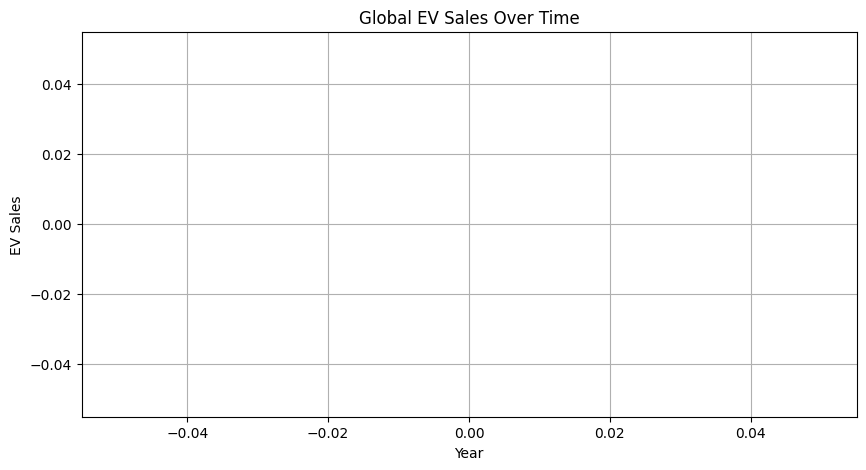

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(ev_df['year'], ev_df['value'], marker='o')

plt.title('Global EV Sales Over Time')
plt.xlabel('Year')
plt.ylabel('EV Sales')
plt.grid(True)

plt.show()

In [9]:
world_df = df[df['region'] == 'World']

print(world_df[['parameter','powertrain']].drop_duplicates())

                          parameter powertrain
3644             Electricity demand         EV
3645                 EV stock share         EV
3646                 EV sales share         EV
3647                       EV sales        BEV
3648                       EV stock        BEV
3649                       EV sales       FCEV
3650                       EV stock       FCEV
3651                       EV sales       PHEV
3652           Oil displacement Mbd         EV
3653  Oil displacement, million lge         EV
3654                       EV stock       PHEV


In [10]:
print(world_df.head(20))

     region    category                      parameter  mode powertrain  year  \
3644  World  Historical             Electricity demand  Cars         EV  2010   
3645  World  Historical                 EV stock share  Cars         EV  2010   
3646  World  Historical                 EV sales share  Cars         EV  2010   
3647  World  Historical                       EV sales  Cars        BEV  2010   
3648  World  Historical                       EV stock  Cars        BEV  2010   
3649  World  Historical                       EV sales  Cars       FCEV  2010   
3650  World  Historical                       EV stock  Cars       FCEV  2010   
3651  World  Historical                       EV sales  Cars       PHEV  2010   
3652  World  Historical           Oil displacement Mbd  Cars         EV  2010   
3653  World  Historical  Oil displacement, million lge  Cars         EV  2010   
3654  World  Historical                       EV stock  Cars       PHEV  2010   
3655  World  Historical     

In [11]:
ev_df = df[
    (df['region'] == 'World') &
    (df['parameter'] == 'EV sales')
]

ev_df = ev_df.groupby('year')['value'].sum().reset_index()

print(ev_df)

    year       value
0   2010      7479.0
1   2011     49038.0
2   2012    120030.0
3   2013    201046.0
4   2014    330094.0
5   2015    550710.0
6   2016    762400.0
7   2017   1183500.0
8   2018   2064500.0
9   2019   2087500.0
10  2020   2987400.0
11  2021   6616000.0
12  2022  10215000.0
13  2023  13808900.0


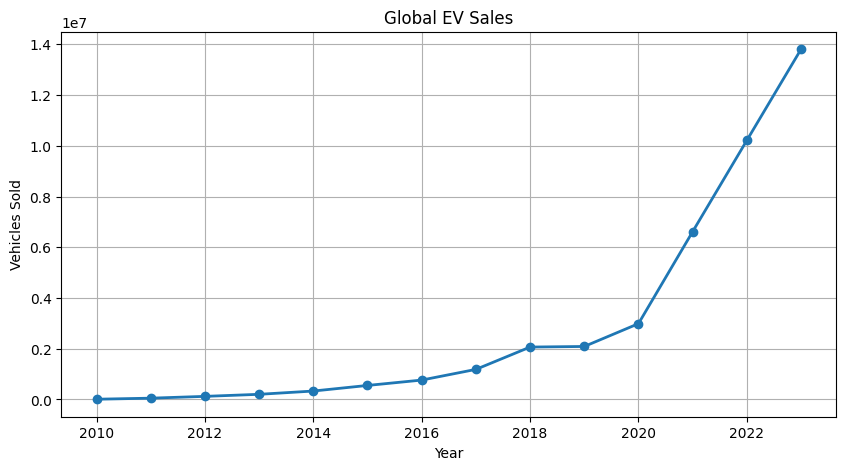

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    ev_df['year'],
    ev_df['value'],
    marker='o',
    linewidth=2
)

plt.title('Global EV Sales')
plt.xlabel('Year')
plt.ylabel('Vehicles Sold')
plt.grid(True)

plt.show()

In [13]:
print(ev_df)

    year       value
0   2010      7479.0
1   2011     49038.0
2   2012    120030.0
3   2013    201046.0
4   2014    330094.0
5   2015    550710.0
6   2016    762400.0
7   2017   1183500.0
8   2018   2064500.0
9   2019   2087500.0
10  2020   2987400.0
11  2021   6616000.0
12  2022  10215000.0
13  2023  13808900.0


In [14]:
ev_df['year'] = pd.to_datetime(ev_df['year'], format='%Y')
ev_df.set_index('year', inplace=True)

print(ev_df.head())

               value
year                
2010-01-01    7479.0
2011-01-01   49038.0
2012-01-01  120030.0
2013-01-01  201046.0
2014-01-01  330094.0


In [15]:
train = ev_df[:-3]
test = ev_df[-3:]

print("Train:", len(train))
print("Test:", len(test))

Train: 11
Test: 3


In [22]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("ARIMA and ETS ready!")

ARIMA and ETS ready!


In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

print("SARIMA ready!")

SARIMA ready!


In [24]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train['value'], order=(1,1,1))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))

print(arima_pred)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA paramete

2021-01-01    3.520930e+06
2022-01-01    4.054458e+06
2023-01-01    4.587983e+06
Freq: YS-JAN, Name: predicted_mean, dtype: float64


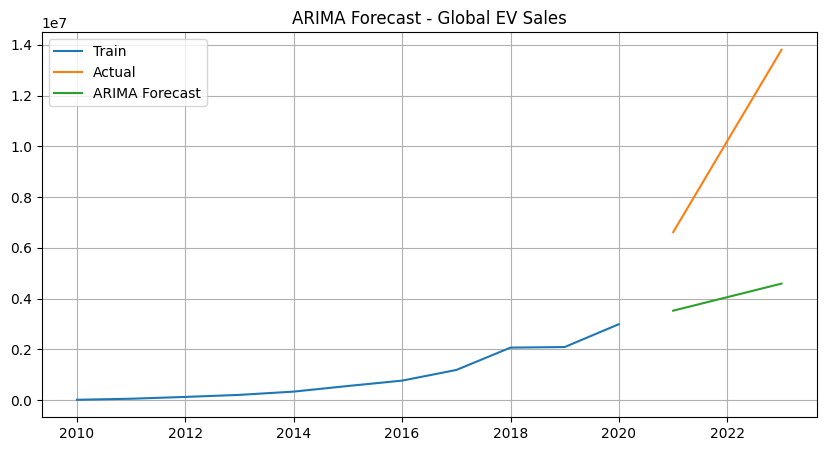

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train.index, train['value'], label='Train')
plt.plot(test.index, test['value'], label='Actual')
plt.plot(test.index, arima_pred, label='ARIMA Forecast')

plt.title('ARIMA Forecast - Global EV Sales')
plt.legend()
plt.grid(True)

plt.show()

In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train['value'],
    order=(1,1,1),
    seasonal_order=(1,1,1,2)
)

sarima_fit = sarima_model.fit(disp=False)

sarima_pred = sarima_fit.forecast(steps=len(test))

print(sarima_pred)

2021-01-01    3.007989e+06
2022-01-01    3.942430e+06
2023-01-01    3.953846e+06
Freq: YS-JAN, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


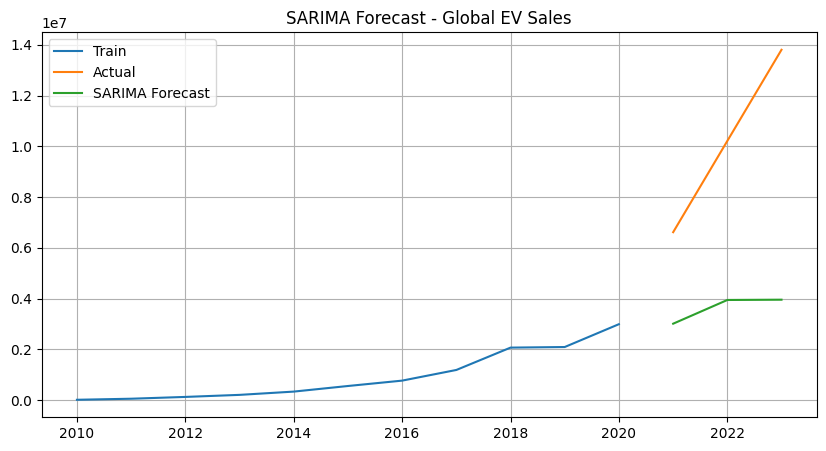

In [27]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train['value'], label='Train')
plt.plot(test.index, test['value'], label='Actual')
plt.plot(test.index, sarima_pred, label='SARIMA Forecast')

plt.title('SARIMA Forecast - Global EV Sales')
plt.legend()
plt.grid(True)

plt.show()

In [28]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_model = ExponentialSmoothing(
    train['value'],
    trend='add'
)

ets_fit = ets_model.fit()

ets_pred = ets_fit.forecast(len(test))

print(ets_pred)

2021-01-01    3.469013e+06
2022-01-01    4.061201e+06
2023-01-01    4.653389e+06
Freq: YS-JAN, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


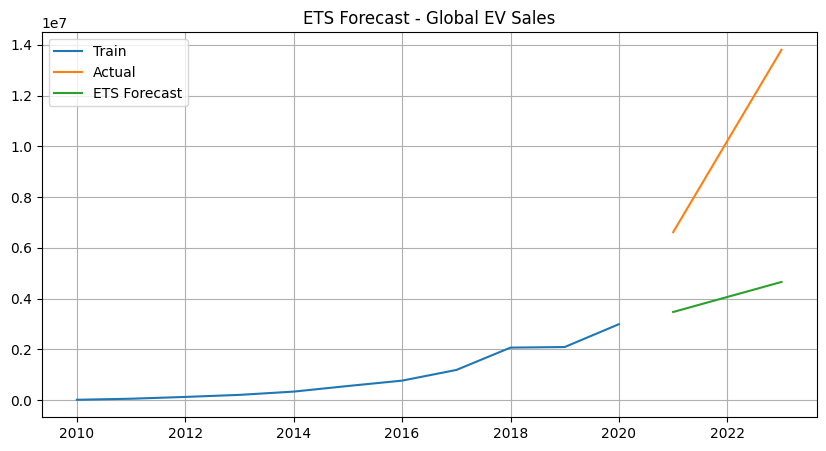

In [29]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train['value'], label='Train')
plt.plot(test.index, test['value'], label='Actual')
plt.plot(test.index, ets_pred, label='ETS Forecast')

plt.title('ETS Forecast - Global EV Sales')
plt.legend()
plt.grid(True)

plt.show()

In [31]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(ev_df[['value']])

X = []
y = []

for i in range(3, len(scaled_data)):
    X.append(scaled_data[i-3:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))

print(X.shape)
print(y.shape)

(11, 3, 1)
(11,)


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(32, activation='relu', input_shape=(3,1)),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

history = model.fit(
    X,
    y,
    epochs=100,
    verbose=0
)

print("Training Complete")

2026-06-22 05:46:44.762579: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782107205.243711      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782107205.375689      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782107206.529868      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782107206.529918      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782107206.529921      58 computation_placer.cc:177] computation placer alr

Training Complete


In [33]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [34]:
 lstm_pred_scaled = model.predict(X)

lstm_pred = scaler.inverse_transform(lstm_pred_scaled)

print(lstm_pred[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
[[2.2239342e+06]
 [2.2711185e+06]
 [2.3397960e+06]
 [2.4461660e+06]
 [2.5838485e+06]]


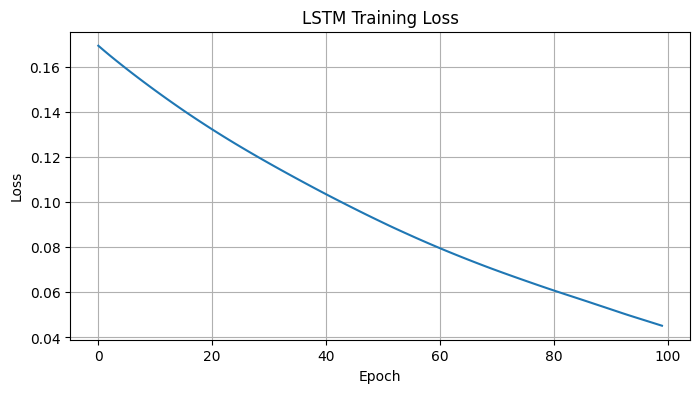

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])

plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.show()